## Polynomial Regression

In [ ]:
# importing the libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X = 6*np.random.rand(100,1)-3
y = 0.5*X**2 + 1.5*X + 2 + np.random.randn(100,1)

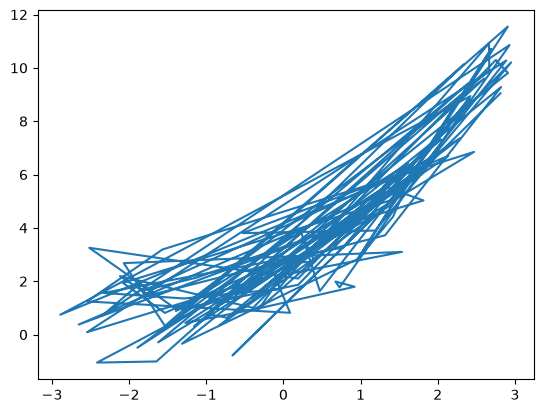

In [3]:
plt.plot(X,y)

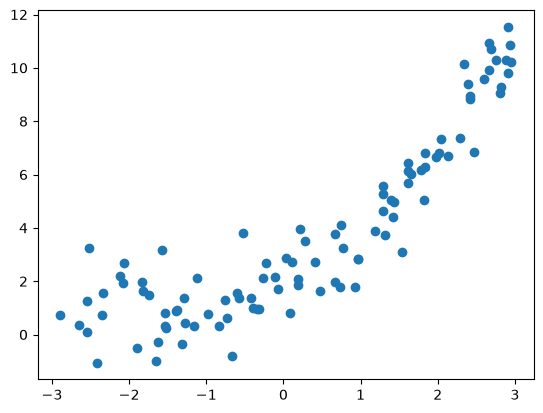

In [4]:
plt.scatter(X,y)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
## Simple linear regression 
from sklearn.linear_model import LinearRegression

regression = LinearRegression()


In [7]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.71]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.33]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[14.96]


In [8]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression.predict(X_test))
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.8962160804387491
0.8904503071297907


Text(0, 0.5, 'Y')

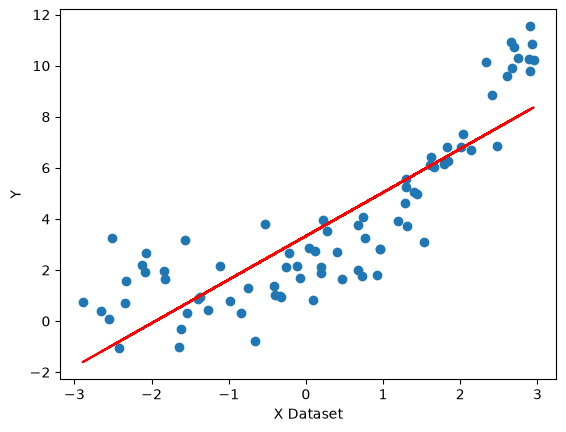

In [9]:
## Visualize

plt.plot(X_train, regression.predict(X_train), color='r')
plt.scatter(X_train, y_train)

plt.xlabel("X Dataset")
plt.ylabel("Y")

In [10]:
## applying polinomial transform

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
X_train_poly

array([[ 1.00000000e+00,  7.68217176e-01,  5.90157629e-01],
       [ 1.00000000e+00, -2.54494344e+00,  6.47673710e+00],
       [ 1.00000000e+00, -2.06894926e+00,  4.28055102e+00],
       [ 1.00000000e+00,  2.69323580e+00,  7.25351910e+00],
       [ 1.00000000e+00,  2.01278795e+00,  4.05131531e+00],
       [ 1.00000000e+00,  1.28768269e+00,  1.65812671e+00],
       [ 1.00000000e+00,  6.69635067e-01,  4.48411123e-01],
       [ 1.00000000e+00,  7.27586992e-01,  5.29382830e-01],
       [ 1.00000000e+00,  1.29444710e+00,  1.67559330e+00],
       [ 1.00000000e+00, -9.80538864e-01,  9.61456463e-01],
       [ 1.00000000e+00,  7.45820589e-01,  5.56248352e-01],
       [ 1.00000000e+00,  2.73480038e-01,  7.47913311e-02],
       [ 1.00000000e+00, -8.34926784e-01,  6.97102735e-01],
       [ 1.00000000e+00,  2.90774926e+00,  8.45500575e+00],
       [ 1.00000000e+00, -3.40288771e-01,  1.15796448e-01],
       [ 1.00000000e+00,  3.66741223e-02,  1.34499124e-03],
       [ 1.00000000e+00,  1.60945838e+00

In [12]:
from sklearn.metrics import r2_score

regression_1 = LinearRegression()

regression_1.fit(X_train_poly, y_train)

y_pred = regression_1.predict(X_test_poly)

sscore = r2_score(y_test, y_pred)

print(sscore)

0.9559720298776433


In [14]:
print(regression_1.coef_)

[[0.         1.50610667 0.51753034]]


In [15]:
print(regression.coef_)

[[1.70674318]]


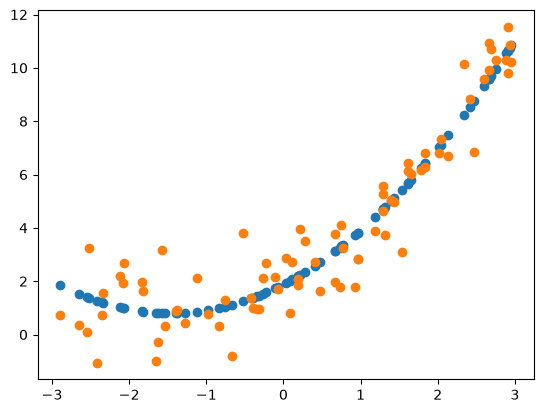

In [19]:
plt.scatter(X_train,regression_1.predict(X_train_poly))
plt.scatter(X_train,y_train)


In [20]:
# prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

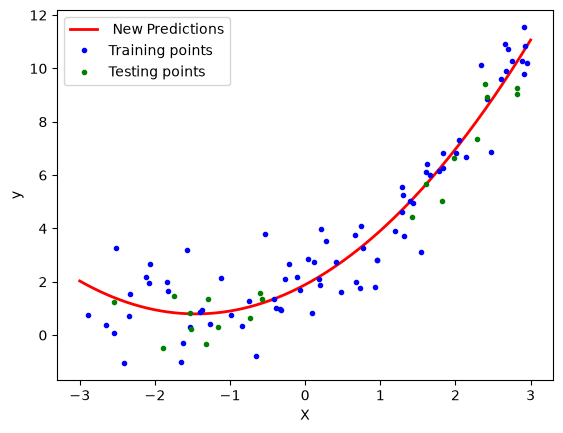

In [22]:
y_new = regression_1.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [25]:
from sklearn.pipeline import Pipeline

In [26]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

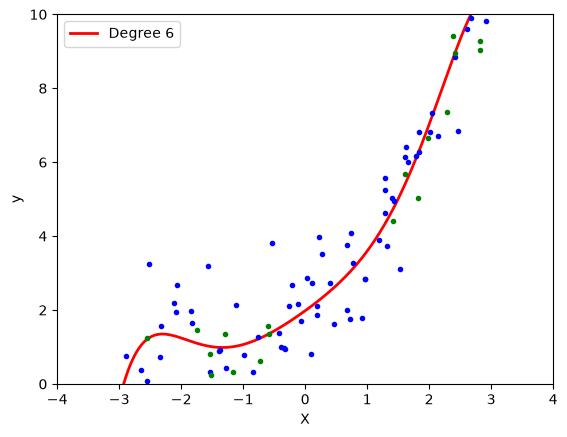

In [27]:
poly_regression(6)